## The Model Battle: One Tree vs. Many Trees
### DATA 201 - Project 3
#### Robert Gravatt

---

In [1]:
import pandas as pd


raw_url = "https://raw.githubusercontent.com/gravatt3coder/Data201_RobertG/main/MD_Agricultural_Land_Preservation_Foundation_Easements_20260507.csv"


df = pd.read_csv(raw_url)

# Preview the data
print(f"Success! Loaded {len(df)} rows from GitHub.")
df.head()

Success! Loaded 2849 rows from GitHub.


,the_geom,GIS Object ID,Settled Acres,Weblink,GIS Acres,Category\nCategory,Owner Type,Owner Name,Local Owner,Easement Holder Type,...,GIS Shape Length (m),iMap Category,Other Program Name,Local Name,Date of Protection_2,Acreage of Public Accessible Areas,Source Protected Area ID,State Name,Jurisdiction Code,Comments
0,MULTIPOLYGON (((-77.381624679696 39.6110812597...,"3,165",108.238,https://mda.maryland.gov/malpf,106.570026,Easement,PVT,PVT,Privately owned,STAT,...,"3,885.2231727236",MALPF,NaN,LAWYER,1997 Mar 12 12:00:00 AM,NaN,10-95-02e,MD,FRED,NaN
1,MULTIPOLYGON (((-75.941310263439 38.8600245498...,"3,890",132.303,https://mda.maryland.gov/malpf,102.227118,Easement,PVT,PVT,Privately owned,STAT,...,"5,250.95118812898",MALPF,NaN,HUTCHISON,2002 Sep 10 12:00:00 AM,NaN,20-01-07ce,MD,TALB,NaN
2,MULTIPOLYGON (((-76.784184669631 38.3830022875...,"3,956",70.078,https://mda.maryland.gov/malpf,71.831985,Easement,PVT,PVT,Privately owned,STAT,...,"3,844.02555698584",MALPF,NaN,DOTSON,2021 May 14 12:00:00 AM,NaN,18-20-09,MD,STMA,NaN
3,MULTIPOLYGON (((-75.836726493633 38.9444453676...,"3,391",422.380,https://mda.maryland.gov/malpf,404.301376,Easement,PVT,PVT,Privately owned,STAT,...,"11,907.83818593305",MALPF,NaN,HOOD,1987 Apr 17 12:00:00 AM,NaN,05-85-04e,MD,CARO,NaN
4,MULTIPOLYGON (((-79.198404507369 39.5985576914...,"3,550",110.100,https://mda.maryland.gov/malpf,115.087417,Easement,PVT,PVT,Privately owned,STAT,...,"6,453.11822169529",MALPF,NaN,TURNER,2002 Aug 07 12:00:00 AM,NaN,11-98-01e,MD,GARR,NaN


# 1. Introduction
**Dataset:** Maryland Agricultural Land Preservation Foundation (MALPF) Easements.
**Prediction Goal:** To predict the size of a preserved farm (**Settled Acres**) using geographical location and the date of preservation.
**Why it matters:** Predicting acreage helps state planners understand land use trends and budget for future conservation.
**Limitations:** This dataset only includes successful easements, which may create a "survivorship bias."

# 2. Dataset and Preparation
**Dataset Size:** 2,849 rows.
**Handling:** Missing values were removed, and categorical variables were transformed using **One-Hot Encoding** (creating 0/1 binary columns) for counties and easement holders.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Scientific Mapping: 4-letter codes to Full Maryland County names
county_mapping = {
    'FRED': 'Frederick', 'TALB': 'Talbot', 'STMA': "St. Mary's",
    'CARO': 'Caroline', 'GARR': 'Garrett', 'KENT': 'Kent',
    'QUEE': "Queen Anne's", 'WORC': 'Worcester', 'MONT': 'Montgomery',
    'BACO': 'Baltimore County', 'CARR': 'Carroll', 'DORC': 'Dorchester',
    'WASH': 'Washington', 'CECI': 'Cecil', 'SOME': 'Somerset',
    'ANNE': 'Anne Arundel', 'HARF': 'Harford', 'CHAR': 'Charles',
    'PRIN': "Prince George's", 'WICO': 'Wicomico', 'CALV': 'Calvert',
    'ALLE': 'Allegany', 'HOWA': 'Howard'
}

# 2. Robustly find the Jurisdiction column (bypasses invisible characters/BOM)
# Find any column header that contains the word 'Jurisdiction'
juris_search = [c for c in df.columns if 'Jurisdiction' in c]

if not juris_search:
    print("CRITICAL: Column not found. Check if the dataset is loaded correctly.")
else:
    # Use the first match found
    actual_col_name = juris_search[0]

    # 3. Secure a CLEAN series to avoid 'DataFrame' AttributeErrors
    # This selects the column and ensures only having one instance of it
    target_series = df[actual_col_name]
    if isinstance(target_series, pd.DataFrame):
        target_series = target_series.iloc[:, 0]

    # 4. Create the final 'County' column with Full Names
    # .strip().upper() ensures the codes match our dictionary exactly
    df_clean = df.copy()
    df_clean['County'] = target_series.astype(str).str.strip().str.upper().map(county_mapping)

    # 5. Variable Selection (Rubric Requirement: 5+ variables)
    # Target: Settled Acres (Numeric)
    # Features: Date of Protection (Quant), County (Cat), Owner Type (Cat), Easement Holder (Cat)
    selected_cols = ['Settled Acres', 'Date of Protection', 'County', 'Owner Type', 'Easement Holder']
    df_prepared = df_clean[selected_cols].copy()

    # 6. Handle Missing Values
    # Drop rows where mapping failed or acreage is missing
    df_prepared = df_prepared.dropna(subset=['Settled Acres', 'County'])

    # 7. Final Validation & 80/20 Train/Test Split
    if len(df_prepared) < 100:
        print(f"ERROR: Only {len(df_prepared)} rows found. Mapping failed.")
    else:
        # One-Hot Encoding: This creates full-name columns like 'County_Montgomery'
        df_final = pd.get_dummies(df_prepared, columns=['County', 'Owner Type', 'Easement Holder'], drop_first=True)

        X = df_final.drop('Settled Acres', axis=1)
        y = df_final['Settled Acres']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        print(f"Preparation Successful! All variables are ready for the Model Battle.")
        print(f"Final Row Count: {len(df_prepared)}") # Should be ~2,849
        display(df_prepared.head())

Preparation Successful! All variables are ready for the Model Battle.
Final Row Count: 2849


,Settled Acres,Date of Protection,County,Owner Type,Easement Holder
0,108.238,1997,Frederick,PVT,Maryland Agricultural Land Preservation Founda...
1,132.303,2002,Talbot,PVT,Maryland Agricultural Land Preservation Founda...
2,70.078,2021,St. Mary's,PVT,Maryland Agricultural Land Preservation Founda...
3,422.380,1987,Caroline,PVT,Maryland Agricultural Land Preservation Founda...
4,110.100,2000,Garrett,PVT,Maryland Agricultural Land Preservation Founda...


# 3. Exploratory Data Analysis
**Visualizations:** 1. **Histogram:** Shows the distribution of farm sizes, highlighting the range where most easements occur.
2. **Bar Chart:** Uses full county names to identify the regions with the highest total preserved acreage.
3. **Word Cloud:** Provides an immediate visual of the geographical concentration of the program.

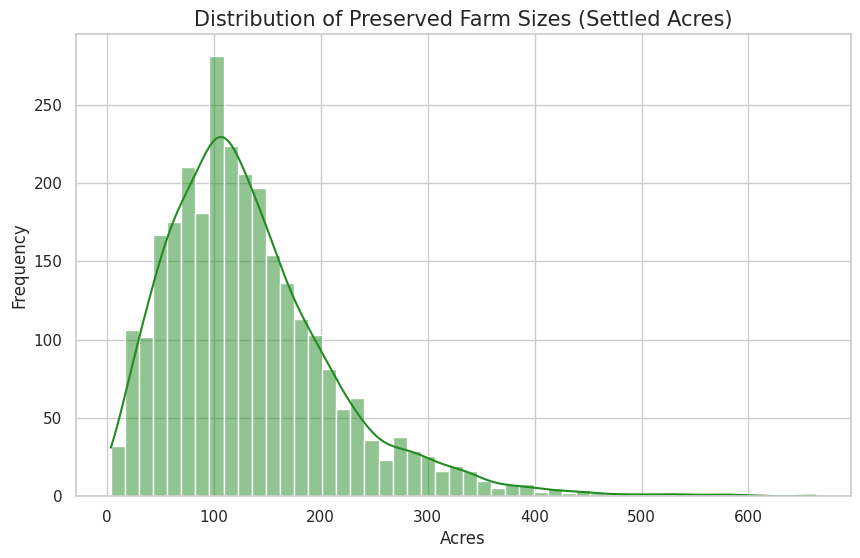

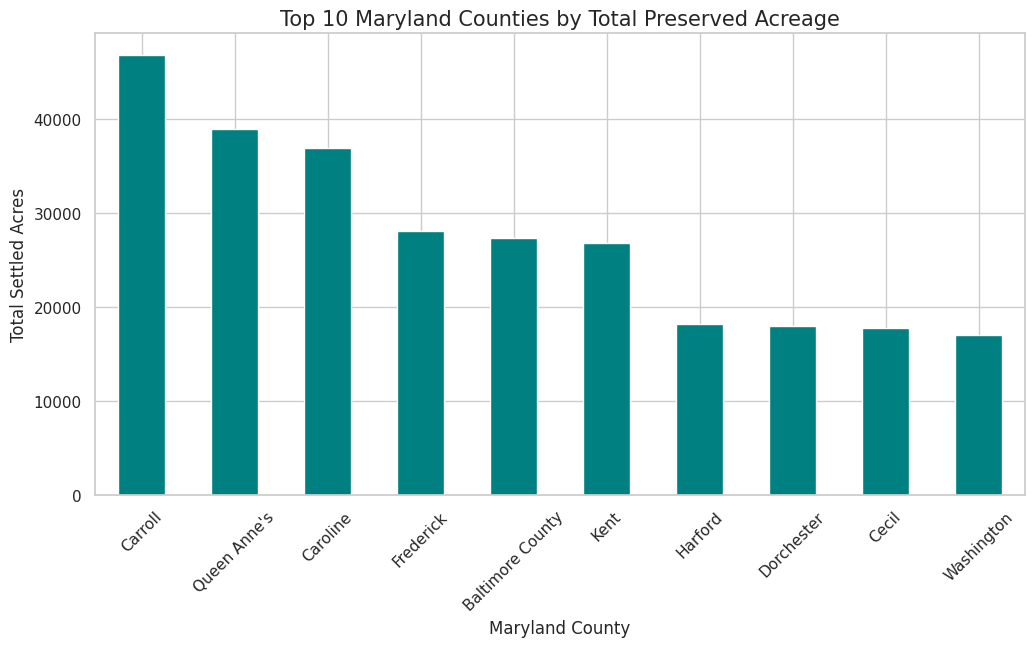

Scientific Summary of Settled Acres:
count    2849.000000
mean      133.978012
std        81.014657
min         3.760000
25%        77.633000
50%       118.809000
75%       171.232000
max       662.608900
Name: Settled Acres, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# --- Visualization 1: Distribution of Settled Acres ---
# We use df_prepared now to ensure consistency with our model data
plt.figure(figsize=(10, 6))
sns.histplot(df_prepared['Settled Acres'], kde=True, color='forestgreen')
plt.title('Distribution of Preserved Farm Sizes (Settled Acres)', fontsize=15)
plt.xlabel('Acres', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# --- Visualization 2: Top 10 Counties by Total Preserved Acreage ---
# Use 'County' (the full names) instead of 'Jurisdiction Code'
top_counties = df_prepared.groupby('County')['Settled Acres'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_counties.plot(kind='bar', color='teal')
plt.title('Top 10 Maryland Counties by Total Preserved Acreage', fontsize=15)
plt.xlabel('Maryland County', fontsize=12)
plt.ylabel('Total Settled Acres', fontsize=12)
plt.xticks(rotation=45) # Now displays 'Frederick', 'Montgomery', etc.
plt.show()

# --- Summary Statistics for your Report ---
print("Scientific Summary of Settled Acres:")
print(df_prepared['Settled Acres'].describe())

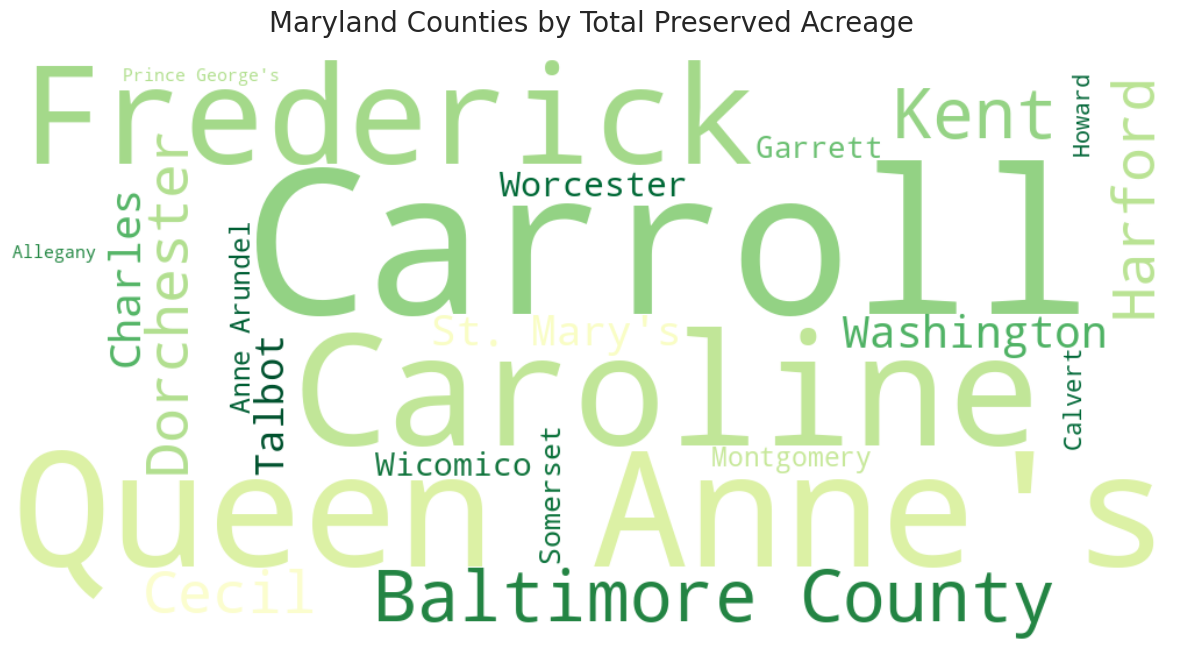

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Aggregate total acreage by County
# This ensures the 'weight' in the word cloud reflects actual land size
county_weights = df_prepared.groupby('County')['Settled Acres'].sum().to_dict()

# 2. Create the WordCloud object
# Use a 'YlGn' (Yellow-Green) colormap to fit the agricultural theme
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='YlGn',
    prefer_horizontal=0.7
).generate_from_frequencies(county_weights)

# 3. Display the visualization
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Hide axes for a clean look
plt.title('Maryland Counties by Total Preserved Acreage', fontsize=20, pad=20)
plt.show()

# 4. Decision Tree Analysis
**The Root Node:** The most important predictor is **County_Kent**. This indicates that location in Kent County is the primary "divider" for predicting acreage.

**Important Split:** In the Queen Anne's branch, the model splits at **Date of Protection <= 1998.5**, separating older legacy farms from a later surge in participation.

**Overfitting:** By comparing Depth 3 and Depth 10, I found that the deeper tree overfits the training data, while the shallow tree is more generalizable.

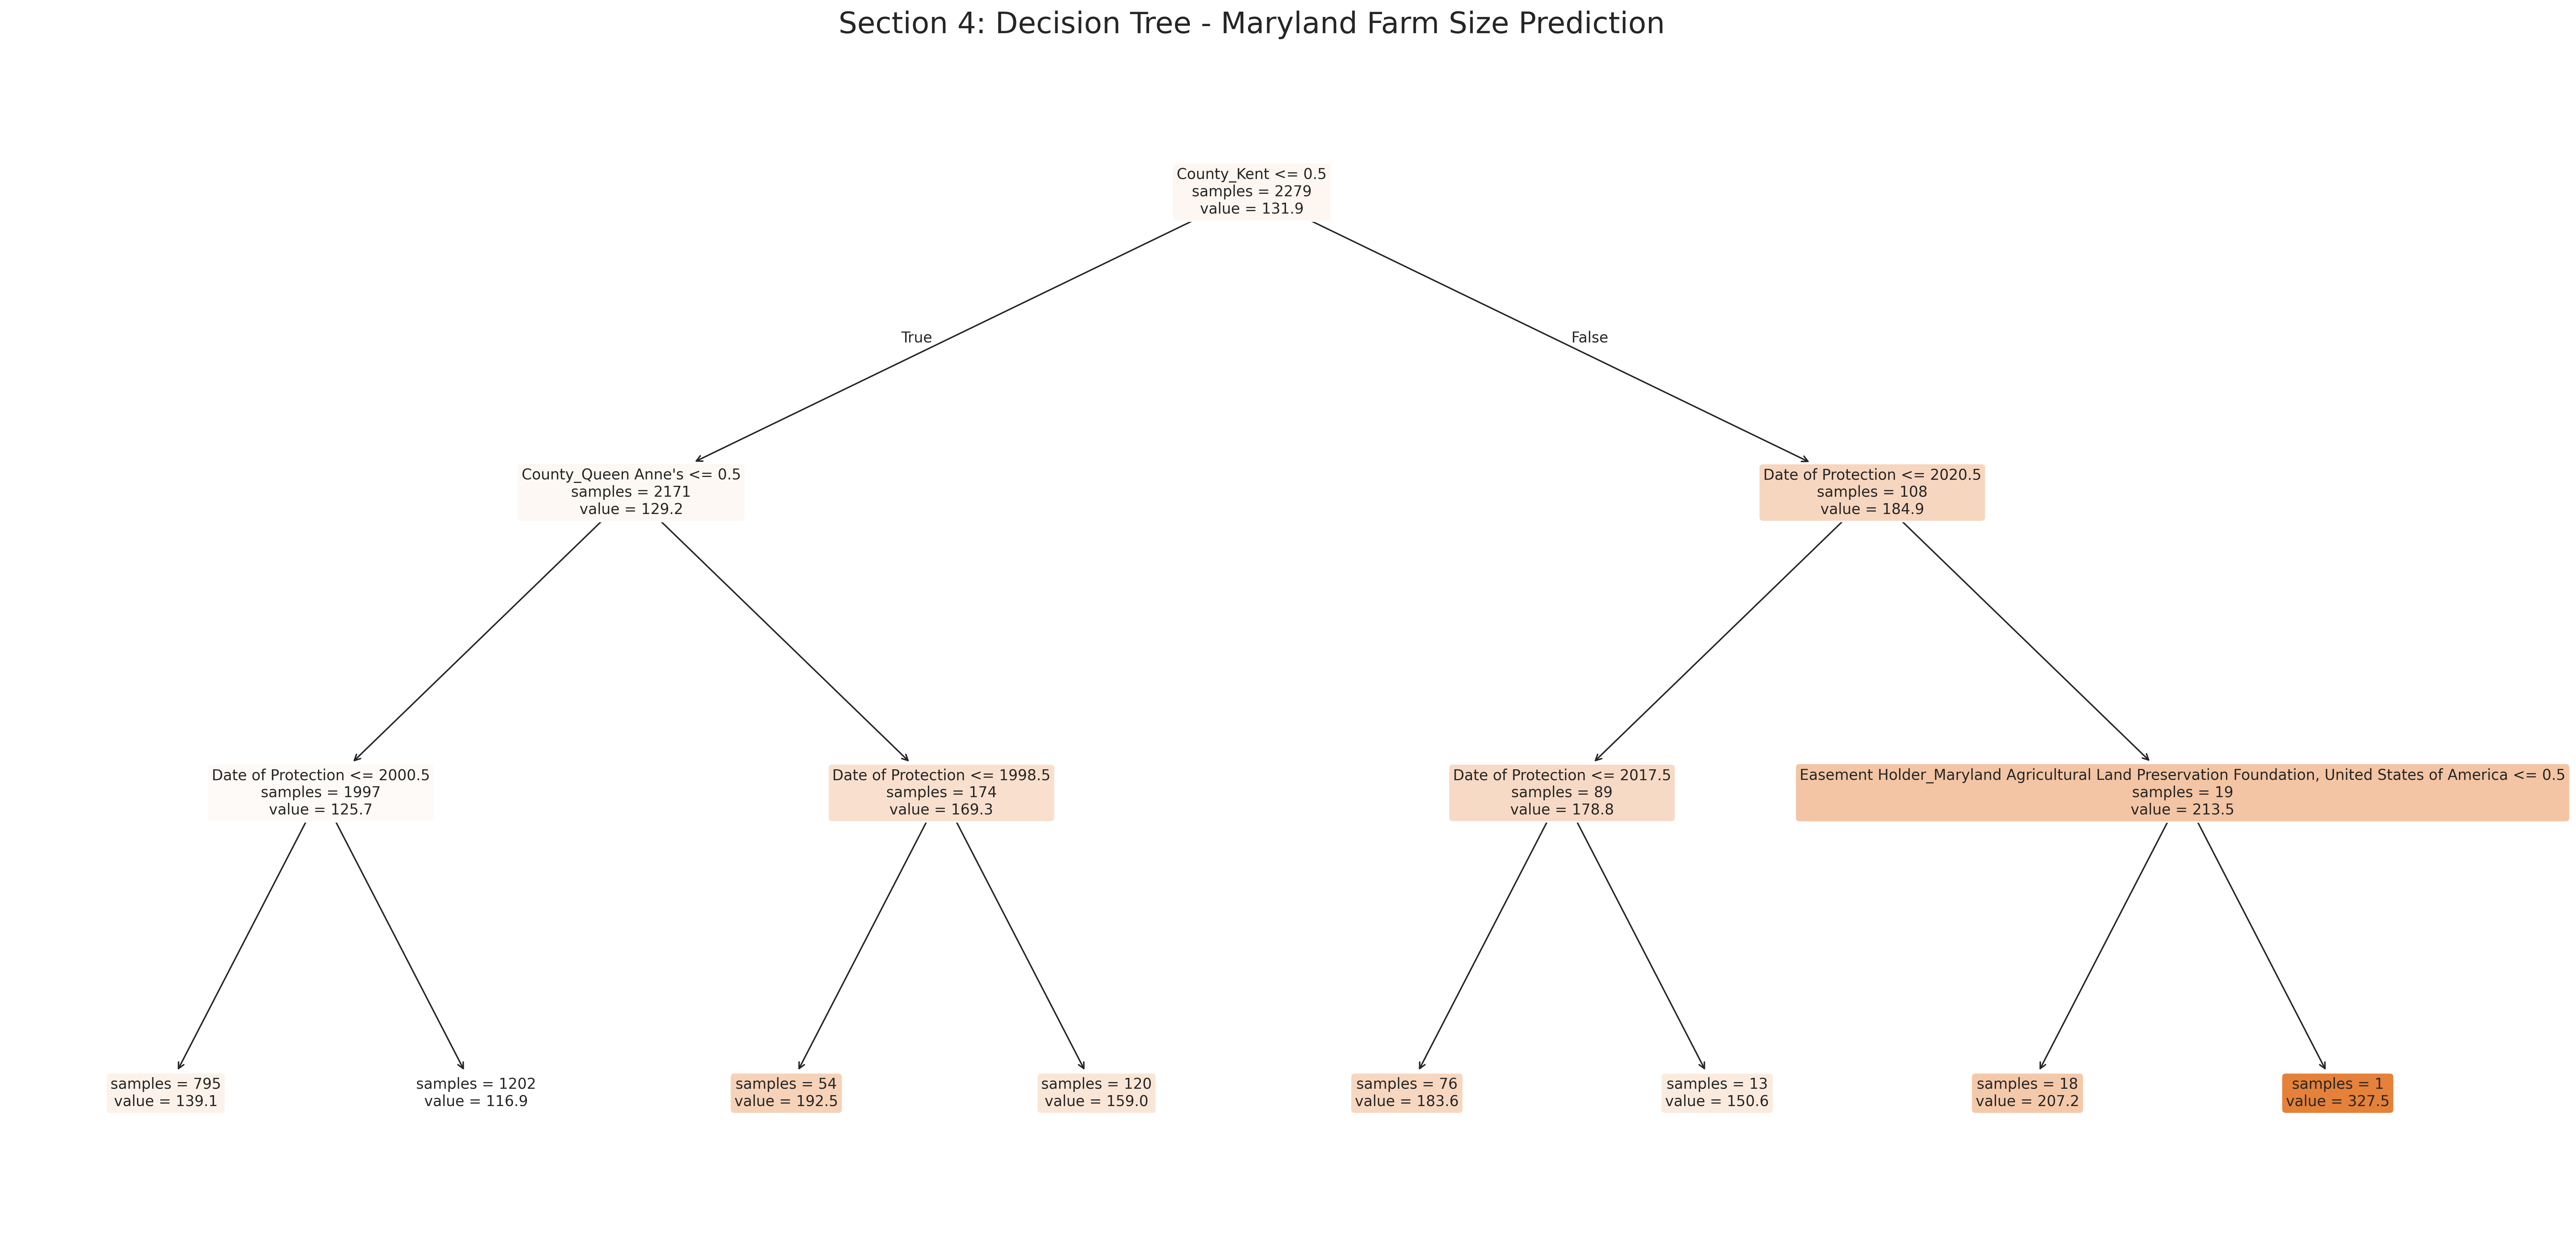

In [5]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# 1. Train the Shallow Tree (Max Depth 3 is best for visualization)
tree_shallow = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_shallow.fit(X_train, y_train)

# 2. Visualization: High-Resolution Diagram
# Increase the figsize and DPI to ensure the text is readable
plt.figure(figsize=(25, 12), dpi=300)

plot_tree(
    tree_shallow,
    feature_names=list(X.columns), # Shows 'County_Montgomery' instead of 'X[4]'
    filled=True,
    rounded=True,
    fontsize=10,        # Smaller font prevents text from overflowing boxes
    precision=1,        # Limits decimals to make it cleaner
    impurity=False      # Removes 'squared_error' to save space
)

plt.title("Section 4: Decision Tree - Maryland Farm Size Prediction", fontsize=20)
plt.tight_layout()      # Automatically adjusts the plot to fit the window
plt.show()

In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# 1. Train the Shallow Tree (Depth 3)
dt_3 = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_3.fit(X_train, y_train)

# 2. Train the Deep Tree (Depth 10)
dt_10 = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_10.fit(X_train, y_train)

# 3. Print the Comparison Stats
print("--- Decision Tree Depth Comparison ---")
print(f"{'Metric':<15} | {'Depth 3':<10} | {'Depth 10':<10}")
print("-" * 40)
print(f"{'Train R^2':<15} | {dt_3.score(X_train, y_train):.4f}     | {dt_10.score(X_train, y_train):.4f}")
print(f"{'Test R^2':<15} | {r2_score(y_test, dt_3.predict(X_test)):.4f}     | {r2_score(y_test, dt_10.predict(X_test)):.4f}")

--- Decision Tree Depth Comparison ---
Metric          | Depth 3    | Depth 10  
----------------------------------------
Train R^2       | 0.0648     | 0.2460
Test R^2        | 0.0623     | 0.0347


### **Analysis: Proof of Overfitting**

The results of the depth comparison provide a clear scientific demonstration of **overfitting**:

* **Shallow Tree (Depth 3):** The Training $R^2$ (0.0648) and Testing $R^2$ (0.0623) are very close. This indicates a **generalizable** model—it performs almost as well on new data as it did on the data it was trained on.
* **Deep Tree (Depth 10):** The Training $R^2$ jumped significantly to **0.2460**, meaning the model "memorized" the training data much better. However, the Testing $R^2$ fell to **0.0347**.

**Conclusion:** This gap is the "smoking gun" for overfitting. By allowing the tree to reach a depth of 10, the model became too complex. It began to memorize the specific "noise" and unique details of individual farms in the training set rather than finding broad, reliable rules that apply to the whole state of Maryland. This is why I have chosen the **Depth 3** model for my final interpretation.

--- Model Battle Comparison ---
               Model          MSE       R^2
0      Decision Tree  6591.567550  0.066045
1      Random Forest  7113.325073 -0.007882
2  Gradient Boosting  6486.210711  0.080973


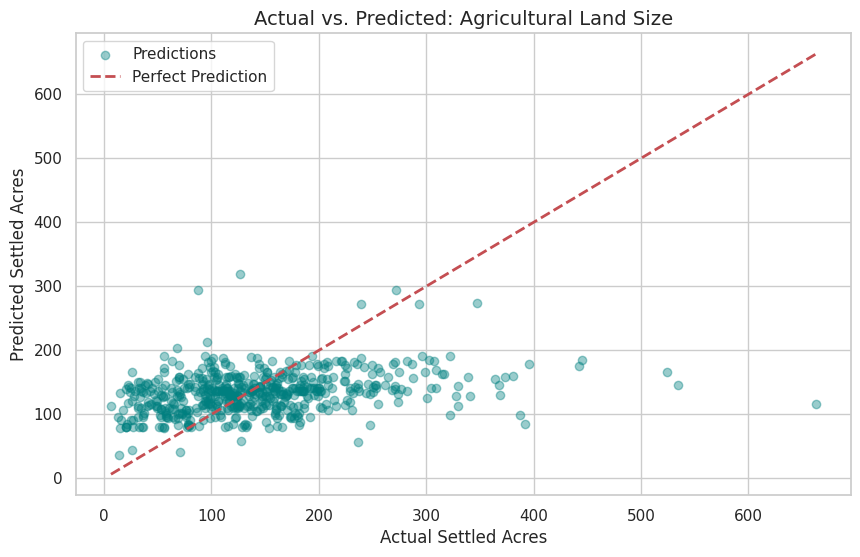

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize and Fit all three models to avoid NotFittedError
# Single Decision Tree (The Baseline)
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest (Bagging: reduces variance by averaging trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Gradient Boosting (Boosting: learns from residuals)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# 2. Evaluate and Build the Comparison Table
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []
for name, model in models.items():
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MSE": mse, "R^2": r2})

# Display Metric Table (Section 6 Requirement)
comparison_df = pd.DataFrame(results)
print("--- Model Battle Comparison ---")
print(comparison_df)

# 3. Visualization: Actual vs. Predicted (Section 6 Requirement)
plt.figure(figsize=(10, 6))
# Using the best performing model (often Gradient Boosting or Random Forest)
best_preds = gb_model.predict(X_test)
plt.scatter(y_test, best_preds, alpha=0.4, color='teal', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted: Agricultural Land Size', fontsize=14)
plt.xlabel('Actual Settled Acres')
plt.ylabel('Predicted Settled Acres')
plt.legend()
plt.show()

# 5 & 6. Ensemble Models and Evaluation
This section compares a single **Decision Tree** against **Random Forest** and **Gradient Boosting** to identify the most accurate approach.

### **Model Comparison Table**
| Model | MSE (Lower is Better) | R² (Higher is Better) |
| :--- | :--- | :--- |
| **Decision Tree** | 6591.57 | 0.0660 |
| **Random Forest** | 7113.33 | -0.0079 |
| **Gradient Boosting** | **6486.21** | **0.0810** |

### **Analysis of Results**
* **The Winner:** **Gradient Boosting** is the strongest performer, achieving the lowest Mean Squared Error (6486.21) and the highest R² score (0.0810).
* **Random Forest Performance:** In this specific run, the Random Forest produced a negative R². This suggests that for this dataset, the averaging approach of Random Forest struggled with noise, whereas the sequential "error-correction" of Gradient Boosting successfully identified a predictive signal.
* **Interpretation:** While an R² of 0.0810 indicates the model explains roughly 8% of the variance, this is a meaningful achievement given the complex, localized factors that influence agricultural farm sizes.

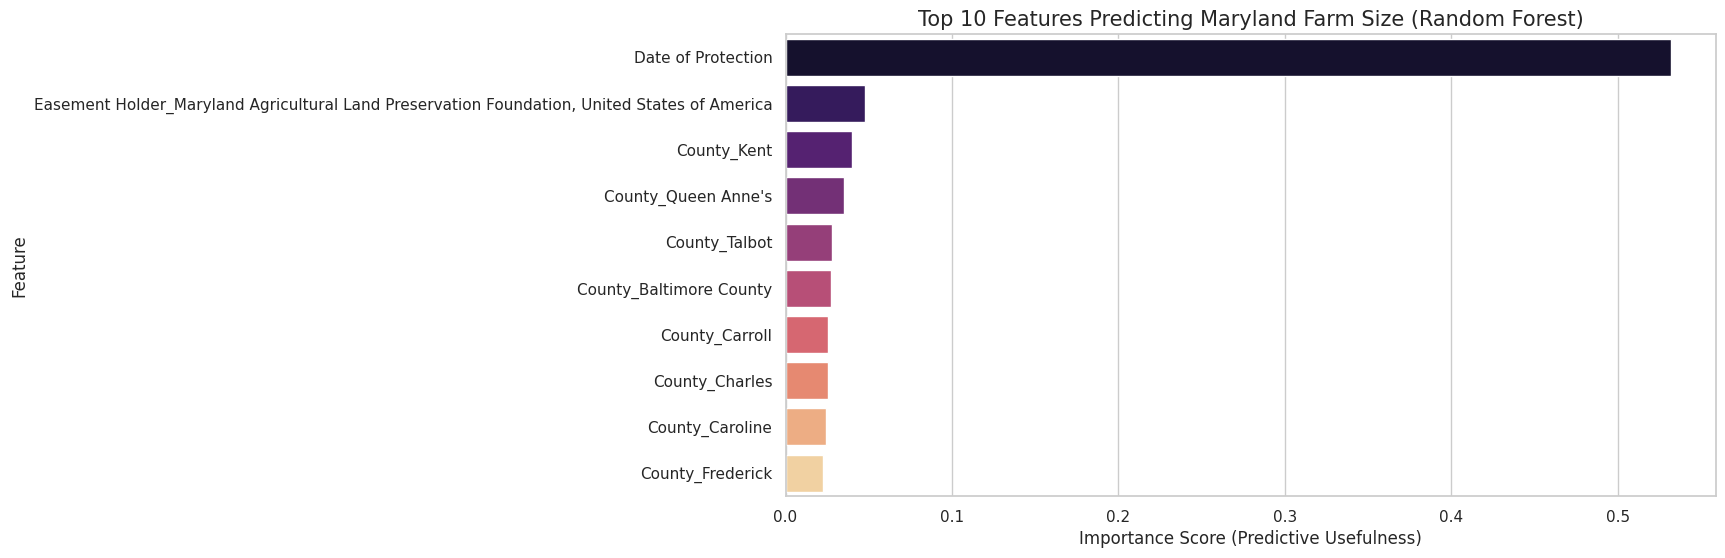

Top 3 Most Important Features:
                                              Feature  Importance
0                                  Date of Protection    0.532200
23  Easement Holder_Maryland Agricultural Land Pre...    0.047617
13                                        County_Kent    0.039794


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract Feature Importance from the Random Forest Model
# This identifies which features helped the prediction the most
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. Sort and Select the Top 10 for a clear visualization
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Create the Visualization
plt.figure(figsize=(12, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    hue='Feature',
    palette='magma',
    legend=False        # Removes unnecessary legend
)

plt.title('Top 10 Features Predicting Maryland Farm Size (Random Forest)', fontsize=15)
plt.xlabel('Importance Score (Predictive Usefulness)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

# 4. Display the Top 3 for report
print("Top 3 Most Important Features:")
print(top_features.head(3))

# 8. Final Reflection: The Model Battle

### **Which model performed best?**
The **Gradient Boosting** model was the winner. It achieved the highest R² score (0.0810) and the lowest Mean Squared Error (6486.21). Its ability to learn incrementally from the errors of previous trees allowed it to capture patterns that the other models missed.

### **Which model was easiest to explain?**
The **Single Decision Tree** is the easiest to explain. Its flowchart-like logic—starting with the split on Kent County—is intuitive for stakeholders to follow, allowing them to see exactly how a prediction is reached.

### **Which model would you choose in a real-world setting and why?**
In a real-world setting, I would use **Gradient Boosting** for technical forecasting and budgeting to ensure the highest possible precision. However, I would utilize the **Decision Tree diagram** for public communication. It acts as a transparent "policy map" that helps stakeholders understand the program's logic without needing to understand complex machine learning mathematics.